In [10]:
import pandas as pd
from deployment_utils import emptyStateRecord, arrHourList, data_format_convertion, unixTime, TOU_15min, convertOutput, NumpyEncoder,convert_floats_to_decimals, currentTime15min, table_to_optimizedStates, stringify_keys, table_to_stateRecord
import optimizer_station_V2 as opt
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib
import os 
import sys 
import cvxpy as cp

CVXPY version: 1.1.18


In [11]:
VAR_DIM_CONSTANT = 96 # 24 hour lookahead - how far do we look ahead while optimizing? This is a safe upper bound since the longest session in SLRP-EV history was 21 hours
COST_DC = 500 # how much the utility charges the station operator for demand charge, in units of cents/kW
DELTA_T = 0.25 # time step in hours
EFF = 1 # power delivery efficiency, in the range [0, 1]
POWER_RATE = 6.6 # max power of chargers in units of kW
FLEXIBILITY_CONSTANT = 0.5 # proportion of power consumed in a regular charging session that the user would have requested if they had chose scheduled

# PG&E time of use tariff from Tugba's simulator, in units of cents/kWh
TOU = np.ones((96,)) * 17.5 # off-peak 0.175  cents / kWh
TOU[64:84] = 36.7 ## 4 pm - 9 pm peak 0.367 cents / kWh
TOU[36:56] = 14.9 ## 9 am - 2 pm super off-peak 0.49 $ / kWh  to cents / kWh
TOU = np.concatenate([TOU, TOU]) # Repeat TOU in case any charging sessions wrap around to the next day

# Grid search for prices
PRICES = np.arange(20, 50, 30) # Define the values for z_reg and z_sch
TARIFF_GRID = [(z_sch, z_reg) for z_reg in PRICES for z_sch in PRICES if z_reg >= z_sch] # Create combinations where z_reg >= z_sch

# Discrete choice model
DCM_CHARGING_SCH_PARAMS = np.array([[ - POWER_RATE * 0.0184 / 2], [POWER_RATE * 0.0184 / 2], [0], [0]])
DCM_CHARGING_REG_PARAMS = np.array([[POWER_RATE * 0.0184 / 2], [- POWER_RATE * 0.0184 / 2], [0], [0.341]])
DCM_LEAVING_PARAMS = np.array([[POWER_RATE * 0.005 / 2], [POWER_RATE * 0.005 / 2], [0], [-1]])
THETA = np.vstack((DCM_CHARGING_SCH_PARAMS.T, DCM_CHARGING_REG_PARAMS.T, DCM_LEAVING_PARAMS.T))

MONTE_CARLO = False # If True, re-evaluate user choices with DCM. If False, assume users choose what they did in reality
VERBOSE = False # If True, print information about how the optimization is going

## Loading in Sessions Dataframe

In [12]:
sessions_df = pd.read_csv("Sessions3.csv")
sessions_df.head(3)

,dcosId,userId,vehicle_model,vehicle_maxChgRate_W,siteId,stationId,connectTime,startChargeTime,Deadline,energyReq_Wh,...,sch_centsPerOverstayHr,Duration,DurationHrs,choice,regular,scheduled,cumEnergy_Wh,peakPower_W,power,lastUpdate
0,24,605,500e,6600,23,7,2020-11-05T10:30:16,2020-11-05T10:31:09,NaN,NaN,...,200.0,0 days 03:43:57,3.73249,REGULAR,1,0,3281.0,6335,"[{'power_W': Decimal('6259'), 'timestamp': Dec...",2020-11-05T14:15:06
1,26,486,Model 3,24000,23,3,2020-11-11T07:39:55,2020-11-11T07:39:59,NaN,NaN,...,200.0,0 days 06:50:07,6.83527,REGULAR,1,0,33458.0,7005,"[{'power_W': Decimal('0'), 'timestamp': Decima...",2020-11-11T14:30:06
2,30,620,Volt,3600,25,12,2020-11-13T16:19:55,2020-11-13T16:20:06,2020-11-14T04:15:00,18400.0,...,300.0,0 days 20:40:02,20.66722,SCHEDULED,0,1,15216.0,3450,"[{'power_W': Decimal('0'), 'timestamp': Decima...",2020-11-14T13:00:08


In [13]:
def get_J(u, z, v, p_dc_sch, p_dc_reg, sub_df, current_time, running_peak):
    """
    Helper function to set up the objective function

    Inputs:
        u: cvxpy variable for power profile
        z: array where [tariff_flex, tariff_asap, tariff_overstay, leave = 1 ] (units: cents/kWh)
        v: array with softmax results [sm_c, sm_uc, sm_y] (sm_y = leave) 
        p_dc_sch: cvxpy variable which represents the peak power if the most recent user chooses scheduled
        p_dc_reg: cvxpy variable which represents the peak power if the most recent user chooses regular
        sub_df: dataframe containing rows of sessions_df that represent active sessions at the time of optimization
        current_time: time of optimization
        running_peak: ruunning peak power this billing cycle
    """
    num_sch_user = 0
    num_reg_user = 0

    existing_sch_obj = 0 # profit objective for existing scheduled
    existing_reg_obj = 0 # profit objective for existing regular
    
    TOU_current_idx = int(np.ceil((current_time.hour + current_time.minute / 60) / DELTA_T)) # current time, beginning of optimization horizon
    for index, row in sub_df.iloc[:-1].iterrows():
        start_time = pd.to_datetime(row['startChargeTime'])
        TOU_start_idx = int(np.ceil((start_time.hour + start_time.minute / 60) / DELTA_T))
        TOU_end_idx = int(np.floor(TOU_start_idx + row['DurationHrs'] / DELTA_T)) # end time index
        N_remain = TOU_end_idx - TOU_current_idx # number of timesteps remaining

        if row['choice'] == 'SCHEDULED':
            price = prices[row['dcosId']][0]
            adj_constant = int((num_sch_user + 1) * VAR_DIM_CONSTANT)
            num_sch_user += 1
            existing_sch_obj += u[adj_constant: (adj_constant + N_remain)].T @ (TOU[TOU_current_idx : TOU_end_idx] - price).reshape(-1, 1)  # FOR NOW ASSUME PERFECT HINDSIGHT
        else: # Assumes we know exactly how long they will stay
            price = prices[row['dcosId']][1]
            if len(power_profiles[row['dcosId']]) > 0 and TOU_end_idx - TOU_current_idx > 0:
                existing_reg_obj += power_profiles[row['dcosId']][-(TOU_end_idx - TOU_current_idx):] @ (TOU[TOU_current_idx : TOU_end_idx] + price)
            else:
                existing_reg_obj += np.array([POWER_RATE] * N_remain) @ (TOU[TOU_current_idx : TOU_end_idx] + price)
            num_reg_user += 1

    sch_power_sum_profile = cp.reshape(u, (VAR_DIM_CONSTANT, num_sch_user + 1)).T
    sch_power_sum_profile = cp.sum(sch_power_sum_profile, axis=0) # Shape: (self.var_dim_constant,)
    
    last_row = sub_df.iloc[-1]
    N_sch = int(np.floor(last_row['DurationHrs'] / DELTA_T)) # how many timesteps the user actually stayed for
    N_reg = last_row['cumEnergy_Wh'] / 1000 / POWER_RATE / DELTA_T # how many time steps would it take the user to charge if they chose regular?
    N_reg_remainder = N_reg % 1 # for that last timestep, what fraction of a timestep is charging needed to satisfy demand?
    N_reg = int(N_reg // 1)
    profit_sch = cp.reshape((TOU[:N_sch] - z[0]), (N_sch, 1))
    
    # Use cvxpy so all variables are cvxpy variables
    new_sch_obj = (u[: N_sch].T @ profit_sch) * DELTA_T

    # This code assumes that we know exactly how long the user will charge for regular (don't necessarily know in reality)
    # Either use simple forecasting they already how or just assume we know it perfectly
    if N_reg == 1:
        new_reg_obj = ((POWER_RATE * N_reg_remainder) * (TOU[N_reg - 1] - z[1])) * DELTA_T
    elif N_reg_remainder > 0:
        new_reg_obj = (cp.sum(POWER_RATE * (TOU[:N_reg - 1] - z[1])) + (POWER_RATE * N_reg_remainder) * (TOU[N_reg - 1] - z[1])) * DELTA_T
    else:
        new_reg_obj = cp.sum(POWER_RATE * (TOU[:N_reg] - z[1])) * DELTA_T
    
    new_sch_obj = new_sch_obj.flatten()[0]
    new_reg_obj = new_reg_obj.flatten()[0]
    new_leave_obj = 0

    current_peak_sch = cp.max(POWER_RATE * num_reg_user + cp.sum(cp.reshape(u, (VAR_DIM_CONSTANT, num_sch_user + 1)).T, axis=0))
    current_peak_reg =  cp.max(POWER_RATE * (num_reg_user + 1) + cp.sum(cp.reshape(u[VAR_DIM_CONSTANT:], (VAR_DIM_CONSTANT, num_sch_user)).T, axis=0))
    
    J0 = ((new_sch_obj + existing_sch_obj + existing_reg_obj) + COST_DC * (p_dc_sch - running_peak)) * v[0]
    J1 = ((new_reg_obj + existing_sch_obj + existing_reg_obj + COST_DC * (p_dc_reg - running_peak))) * v[1]
    J2 = (new_leave_obj + existing_sch_obj + existing_reg_obj + COST_DC * 0) * v[2]
    
    J = J0 + J1 + J2

    return J, [J0, J1, J2], current_peak_sch, current_peak_reg

In [14]:
def argmin_u(z, v, sub_df, current_time, running_peak):
    """
    Function to minimize charging cost. Flexible charging with variable power schedule
    
        Inputs: 
        z: array where [tariff_flex, tariff_asap, tariff_overstay, leave = 1 ]
        v: array with softmax results [sm_c, sm_uc, sm_y] (sm_y = leave)
        sub_df: dataframe containing rows of sessions_df that represent active sessions at the time of optimization
        current_time: time of optimization
        running_peak: ruunning peak power this billing cycle
    """

    e_need_lst = []
    N_remain_lst = []
    price_lst = []
    end_charge_times = (pd.to_datetime(sub_df['startChargeTime']) + pd.to_timedelta(sub_df['DurationHrs'], unit='h') - pd.Timedelta(minutes=15)).dt.floor('15T')

    last_row = sub_df.iloc[-1]
    TOU_current_idx = int(np.ceil((current_time.hour + current_time.minute / 60) / DELTA_T)) # current time, beginning of optimization horizon
    if last_row['choice'] == 'SCHEDULED':
        e_need = last_row['energyReq_Wh'] / 1000 / DELTA_T # Division by 1000 to go from Wh to kWh TODO update to account for past charging
        start_time = pd.to_datetime(last_row['startChargeTime'])
        TOU_start_idx = int(np.ceil((start_time.hour + start_time.minute / 60) / DELTA_T))
        TOU_end_idx = int(np.floor(TOU_start_idx + last_row['DurationHrs'] / DELTA_T)) # end time index
        N_remain = TOU_end_idx - TOU_current_idx # number of timesteps remaining
        start_time = pd.to_datetime(last_row['startChargeTime'])
        current_time = (current_time + pd.Timedelta(minutes=15)).floor('15T')
        power_profile_current_idx = int(np.ceil((current_time - start_time).total_seconds() / 3600 / DELTA_T))
        if len(power_profiles[last_row['dcosId']]) > 0:
            e_need -= sum(power_profiles[last_row['dcosId']][:power_profile_current_idx]) # if user has already consumed some power, subtract it from their demand
            if e_need < 0: # handle numerical imprecision and set completed charging sessions to exactly zero
                e_need = 0
        if e_need  > N_remain * POWER_RATE * DELTA_T: # if user requests an infeasible amount of power
            e_need = N_remain * POWER_RATE * DELTA_T
        e_need_lst.append(e_need)
        N_remain_lst.append(N_remain)
    else:
        e_need = last_row['cumEnergy_Wh'] / 1000 * FLEXIBILITY_CONSTANT
        start_time = pd.to_datetime(last_row['startChargeTime'])
        TOU_start_idx = int(np.ceil((start_time.hour + start_time.minute / 60) / DELTA_T))
        TOU_end_idx = int(np.floor(TOU_start_idx + last_row['DurationHrs'] / DELTA_T)) # end time index
        N_remain = TOU_end_idx - TOU_current_idx # number of timesteps remaining
        if e_need  > N_remain * POWER_RATE * DELTA_T: # if user requests an infeasible amount of power
            e_need = N_remain * POWER_RATE * DELTA_T
        e_need_lst.append(e_need)
        N_remain_lst.append(N_remain)
    
    for index, row in sub_df.iloc[:-1][sub_df['choice'] == 'SCHEDULED'][pd.to_datetime(sub_df['Deadline']) > current_time].iterrows():
        e_need = row['energyReq_Wh'] / 1000 / DELTA_T # Division by 1000 to go from Wh to kWh 
        start_time = pd.to_datetime(last_row['startChargeTime'])
        TOU_start_idx = int(np.ceil((start_time.hour + start_time.minute / 60) / DELTA_T))
        TOU_end_idx = int(np.floor(TOU_start_idx + row['DurationHrs'] / DELTA_T)) # end time index
        N_remain = TOU_end_idx - TOU_current_idx # number of timesteps remaining
        start_time = pd.to_datetime(row['startChargeTime'])
        current_time = (current_time + pd.Timedelta(minutes=15)).floor('15T')
        power_profile_current_idx = int(np.ceil((current_time - start_time).total_seconds() / 3600 / DELTA_T))
        
        if len(power_profiles[row['dcosId']]) > 0:
            e_need -= sum(power_profiles[row['dcosId']][:power_profile_current_idx]) # if user has already consumed some power, subtract it from their demand
            if e_need < 0: # handle numerical imprecision and set completed charing sessions to exactly zero
                e_need = 0
        if e_need  > N_remain * POWER_RATE * DELTA_T: # if user requests an infeasible amount of power
            e_need = N_remain * POWER_RATE * DELTA_T
        e_need_lst.append(e_need)
        N_remain_lst.append(N_remain)
        if prices[row['dcosId']]:
            price_lst.append(prices[row['dcosId']])
        else:
            price_lst.append(row['sch_centsPerHr'])

    num_sch_user = len(e_need_lst) # number of scheduled users
    ### Decision Variables
    e_delivered = cp.Variable(shape = ((VAR_DIM_CONSTANT + 1) * num_sch_user, 1)) # energy delivered
    u = cp.Variable(shape = (VAR_DIM_CONSTANT * num_sch_user, 1)) # charging profile (extra scheduled user profile added in case new user chooses scheduled
    p_dc_sch = cp.Variable(shape = 1)
    p_dc_reg = cp.Variable(shape = 1)    
    
    ### Constraints incorporate all SCH users
    constraints = [u >= 0]
    
    # Iterate through all existing flex users
    for i in range(num_sch_user):
        e_need = e_need_lst[i]
        N_remain = N_remain_lst[i]
        
        e_start = int(i * (VAR_DIM_CONSTANT + 1))
        e_end = int(i * (VAR_DIM_CONSTANT + 1) + N_remain)
        e_max = int(i * (VAR_DIM_CONSTANT + 1) + VAR_DIM_CONSTANT)
        u_start = int(i * VAR_DIM_CONSTANT)
        u_end = int(i * VAR_DIM_CONSTANT + N_remain)

        constraints += [u[u_start: u_end] <= POWER_RATE]
        constraints += [e_delivered[e_start] == 0]
        constraints += [e_delivered[e_end] >= e_need]
        constraints += [e_delivered[e_start: e_max+1] <= e_need] # Implication: e_end = e_need.
    
        # Charging dynamics within each user
        for j in range(VAR_DIM_CONSTANT):
            constraints += [e_delivered[j + e_start + 1] == e_delivered[j + e_start] + (float(EFF) * DELTA_T * u[u_start + j])]

    ### Solve
    J, J_array, current_peak_sch, current_peak_reg = get_J(u, z, v, p_dc_sch, p_dc_reg, sub_df, current_time, running_peak)
    
    # Demand charge constraints
    constraints += [running_peak <= p_dc_sch]
    constraints += [running_peak <= p_dc_reg]
    constraints += [current_peak_sch <= p_dc_sch]
    constraints += [current_peak_reg <= p_dc_reg]
    
    obj = cp.Minimize(J)
    prob = cp.Problem(obj, constraints)
    prob.solve()
    if prob.status != 'optimal':
        print(prob.status)
        print("Gurobi failed, cant solve for power")
        prob.solve(solver='GUROBI',verbose=True)
    
    return u.value, e_delivered.value, p_dc_sch.value, p_dc_reg.value, J, J_array

In [15]:
from scipy.special import softmax

def grid_search(current_time, running_peak):
    """
    Function to search over a grid of price combinations minimize charging cost.
    
        Inputs: 
        current_time: time of optimization
        running_peak: ruunning peak power this billing cycle
    """
    sub_df = sessions_df[pd.to_datetime(sessions_df['startChargeTime']) <= current_time]
    end_charge_times = (pd.to_datetime(sub_df['startChargeTime']) + pd.to_timedelta(sub_df['DurationHrs'], unit='h') - pd.Timedelta(minutes=15)).dt.floor('15T')
    sub_df = sub_df[end_charge_times >= current_time]
    
    # if after filtering there is no updating to be done, return null result
    if len(sub_df) == 0:
        return None, sub_df
        
    grid_search_results = {}
    zk = [100, 100, 500, 0]
    for (z_sch_k, z_reg_k) in TARIFF_GRID:
        zk[3] = 1 # leave price TODO WHY WERE THESE SET TO 1?
        zk[2] = 1 # overstay fee
        zk[0] =  z_sch_k # scheduled price
        zk[1] =  z_reg_k # regular price
        vk = softmax(THETA @ zk).reshape(3,1)
        
        uk_flex, e_deliveredk_flex, p_dc_sch_k, p_dc_reg_k, J, J_array = argmin_u(zk, vk, sub_df, current_time, running_peak)
        grid_search_results[ (z_sch_k, z_reg_k) ] = {}
        grid_search_results[ (z_sch_k, z_reg_k) ]["J"] =  J.value
        grid_search_results[ (z_sch_k, z_reg_k) ]["J_arr"] =  J_array
        grid_search_results[ (z_sch_k, z_reg_k) ]["u"] =  uk_flex
        grid_search_results[ (z_sch_k, z_reg_k) ]["p_dc_sch_k"] =  p_dc_sch_k
        grid_search_results[ (z_sch_k, z_reg_k) ]["p_dc_reg_k"] =  p_dc_reg_k

    return grid_search_results, sub_df

In [16]:
april_2024 = sessions_df[(pd.to_datetime(sessions_df['connectTime']).dt.year == 2021) & (pd.to_datetime(sessions_df['connectTime']).dt.month == 4)]
april_2024 = april_2024[april_2024['DurationHrs'] > 0.5]
april_2024 = april_2024[april_2024['cumEnergy_Wh'] > 0]
april_2024.head(10)

,dcosId,userId,vehicle_model,vehicle_maxChgRate_W,siteId,stationId,connectTime,startChargeTime,Deadline,energyReq_Wh,...,sch_centsPerOverstayHr,Duration,DurationHrs,choice,regular,scheduled,cumEnergy_Wh,peakPower_W,power,lastUpdate
173,293,603,Prius Prime,8800,25,13,2021-04-01T06:29:44,2021-04-01T06:29:53,2021-04-01T08:15:00,8096.0,...,300.0,0 days 01:50:15,1.83749,SCHEDULED,0,1,3910.0,3400,"[{'power_W': Decimal('0'), 'timestamp': Decima...",2021-04-01T08:20:08
174,294,745,Model Y,250000,23,7,2021-04-01T06:54:00,2021-04-01T06:54:08,2021-04-01T15:45:00,26104.0,...,500.0,0 days 08:45:59,8.76638,SCHEDULED,0,1,33771.0,7041,"[{'power_W': Decimal('2479'), 'timestamp': Dec...",2021-04-01T15:40:07
175,295,721,Model X,5000,25,11,2021-04-01T08:54:43,2021-04-01T08:56:36,NaN,NaN,...,300.0,0 days 01:53:37,1.89361,REGULAR,1,0,8953.0,6558,"[{'power_W': Decimal('6540'), 'timestamp': Dec...",2021-04-01T10:50:13
176,296,746,Model 3,11500,25,12,2021-04-01T09:04:56,2021-04-01T09:05:09,2021-04-01T18:00:00,46459.0,...,500.0,0 days 07:49:59,7.83305,SCHEDULED,0,1,49941.0,6810,"[{'power_W': Decimal('6770'), 'timestamp': Dec...",2021-04-01T16:55:08
177,297,631,Clarity PHEV,6600,25,16,2021-04-01T12:21:17,2021-04-01T12:21:28,NaN,NaN,...,500.0,0 days 04:33:40,4.56111,REGULAR,1,0,5843.0,6697,"[{'power_W': Decimal('6697'), 'timestamp': Dec...",2021-04-01T16:55:08
178,298,603,Prius Prime,8800,25,12,2021-04-02T06:22:12,2021-04-02T06:22:23,2021-04-02T08:15:00,8096.0,...,300.0,0 days 01:52:44,1.87888,SCHEDULED,0,1,4387.0,3359,"[{'power_W': Decimal('1256'), 'timestamp': Dec...",2021-04-02T08:15:07
179,299,721,Model X,5000,25,15,2021-04-02T08:54:00,2021-04-02T08:56:41,NaN,NaN,...,300.0,0 days 00:58:27,0.97416,REGULAR,1,0,5995.0,6559,"[{'power_W': Decimal('6546'), 'timestamp': Dec...",2021-04-02T09:55:08
180,301,615,Model 3,170000,25,16,2021-04-02T10:54:28,2021-04-02T10:55:57,2021-04-02T16:00:00,38023.0,...,500.0,0 days 04:19:11,4.31972,SCHEDULED,0,1,28458.0,6958,"[{'power_W': Decimal('6949'), 'timestamp': Dec...",2021-04-02T15:15:08
182,304,603,Prius Prime,8800,25,12,2021-04-05T06:29:00,2021-04-05T06:29:12,2021-04-05T08:30:00,8096.0,...,500.0,0 days 01:35:56,1.59888,SCHEDULED,0,1,4031.0,0,"[{'power_W': Decimal('0'), 'timestamp': Decima...",2021-04-05T08:05:08
184,306,486,Model 3,24000,23,7,2021-04-05T08:08:31,2021-04-05T08:09:37,2021-04-05T17:00:00,45161.0,...,500.0,0 days 08:55:30,8.92500,SCHEDULED,0,1,45259.0,7100,"[{'power_W': Decimal('14'), 'timestamp': Decim...",2021-04-05T17:05:07


In [17]:
power_profiles = {c : [] for c in sessions_df['dcosId']}
prices = {c : None for c in sessions_df['dcosId']}

running_peak = 0

for startChargeTime in pd.to_datetime(april_2024['startChargeTime'].iloc[:30]):
    grid_search_results, sub_df = grid_search(startChargeTime, running_peak)

    if len(sub_df) > 0:
        min_key = min(grid_search_results, key=lambda k: grid_search_results[k]['J'])
        min_J = grid_search_results[min_key]['J']
        u = grid_search_results[min_key]['u']
        dc_sch = grid_search_results[min_key]['p_dc_sch_k']
        dc_reg = grid_search_results[min_key]['p_dc_reg_k']
    
        num_sch_user = 0
        for index, row in sub_df.iloc[:-1][sub_df['choice'] == 'SCHEDULED'][pd.to_datetime(sub_df['Deadline']) > startChargeTime].iterrows():
            N_remain = int(((pd.to_datetime(row['Deadline']) - startChargeTime).total_seconds() / 3600) / DELTA_T)
            adj_constant = int((num_sch_user + 1) * VAR_DIM_CONSTANT)
            num_sch_user += 1
            power_profiles[row['dcosId']][-N_remain:] = u[adj_constant: (adj_constant + N_remain)].flatten()
    
        last_row = sub_df.iloc[-1]
        prices[last_row['dcosId']] = min_key

        if MONTE_CARLO:
            zk = [min_key[0], min_key[1], 500, 1]
            vk = softmax(THETA @ zk)
            normalized_probs = vk[:2] / vk[:2].sum() # only simulate sch/reg choices, no leaving in the simulation
            choice = np.random.choice(['SCHEDULED', 'REGULAR'], p=normalized_probs)
        else:
            zk = [min_key[0], min_key[1], 500, 1]
            vk = softmax(THETA @ zk)
            choice = last_row['choice']

        if choice == 'SCHEDULED':
            running_peak = max(running_peak, dc_sch)
            power_profiles[last_row['dcosId']] = u[:VAR_DIM_CONSTANT].flatten()
        else:
            running_peak = max(running_peak, dc_reg)
            start_time = pd.to_datetime(row['startChargeTime'])
            TOU_start_idx = int(np.ceil((start_time.hour + start_time.minute / 60) / DELTA_T))
            TOU_end_idx = int(np.floor(TOU_start_idx + last_row['DurationHrs'] / DELTA_T)) # end time index
            N_remain = TOU_end_idx - TOU_start_idx # number of timesteps remaining
            N_reg = last_row['cumEnergy_Wh'] / 1000 / POWER_RATE / DELTA_T # how many time steps would it take the user to charge if they chose regular?
            N_reg_remainder = N_reg % 1 # for that last timestep, what fraction of a timestep is charging needed to satisfy demand?
            N_reg = int(N_reg // 1)            
            power_profiles[last_row['dcosId']] = np.zeros(N_remain)
            power_profiles[last_row['dcosId']][:N_reg] = np.array([POWER_RATE] * N_reg)
            if N_reg < N_remain and N_reg_remainder > 0:
                power_profiles[last_row['dcosId']][N_reg] = POWER_RATE * N_reg_remainder

        if VERBOSE:
            print("---------------------------------------------------------------------")
            print('Done with optimization at', startChargeTime)
            print("Optimal prices:", min_key)
            print('Probabilities', vk)
            print('Optimized delivery of', round(sum(u[:VAR_DIM_CONSTANT])[0] / 4, 2), f'kW to session #{last_row["dcosId"]}')
            print('Number of active sessions:', len(sub_df))
            print('Peak options', dc_sch[0], dc_reg[0])
            print('Peak thus far', running_peak[0])

In [18]:
power_profiles
filtered_power_profiles = {k: v for k, v in power_profiles.items() if len(v) > 0}

agg_power_profile = np.zeros(30 * VAR_DIM_CONSTANT)

for key, power_profile in filtered_power_profiles.items():
    matching_row = sessions_df.loc[sessions_df['dcosId'] == key]
    row = matching_row.squeeze() 
    start_time = pd.to_datetime(row['startChargeTime'])
    start_of_month = start_time.replace(day=1, hour=0, minute=0, second=0, microsecond=0)
    i = int(np.ceil((start_time - start_of_month).total_seconds() / (15 * 60)))
    agg_power_profile[i : i+len(power_profile)] += power_profile.flatten()

In [19]:
filtered_power_profiles.keys()

dict_keys([293, 294, 295, 296, 297, 298, 299, 301, 304, 306, 308, 310, 311, 312, 313, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329])

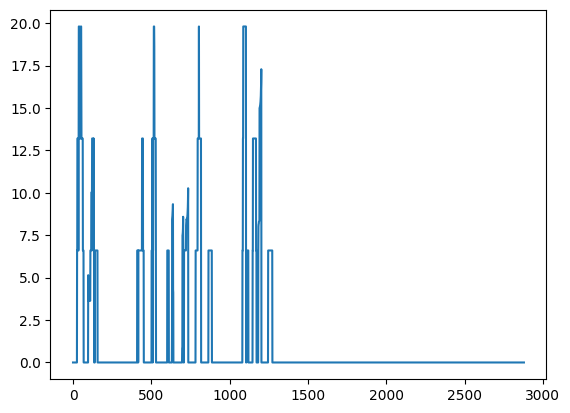

In [20]:
plt.plot(agg_power_profile)

In [21]:
max(agg_power_profile)

19.799999999999997